# Practical 2: CO2 Concentration Time Series Analysis
## Dataset: CO2 Concentration (Monthly CO2 Levels)

---
### 📘 Beginner's Concept: Multi-Column Dates & Additive Decomposition
In real-world data science, dates are often split across separate columns (e.g. `Year=1958`, `Month=3`). Before performing time series analysis, we must combine them into a single standardized datetime format (`1958-03`).

Additionally, unlike Practical 1 (AirPassengers) where seasonal oscillation height expanded as passengers grew, **CO2 Concentration** seasonal fluctuations remain constant in height over time. This requires an **Additive Model** ($Y_t = 	ext{Trend}_t + 	ext{Seasonal}_t + 	ext{Residual}_t$).
---

### Step 1: Import Libraries
**Why we write this code:**
Import numpy/pandas for data handling, matplotlib/seaborn for graphs, statsmodels for decomposition, exponential smoothing, and ADF/KPSS stationarity testing, and pymannkendall for trend testing.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.seasonal import seasonal_decompose

### Step 2: Read Excel File & Inspect Multi-Column Structure
**Why we write this code:**
Load `CO2 Concentration.xls` and display the first 5 rows to see separate `Year` and `Month` numeric columns.

In [2]:
df = pd.read_csv("CO2 Concentration.xls")
df.head(5)

,Year,Month,CO2 Concentration
0,1975,1,330.62
1,1975,2,331.40
2,1975,3,331.87
3,1975,4,333.18
4,1975,5,333.92


In [3]:
df.shape

(144, 3)

### Step 3: Combine Year and Month into Unified ISO Datetime Index
**Why we write this code:**
- `df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2)`: Combines numeric `1958` and `3` into string `"1958-03"`. `zfill(2)` ensures single-digit months have a leading zero.
- `pd.to_datetime(...)`: Converts strings into official pandas Datetime timestamps.
- `df.set_index("year_month")`: Sets the datetime column as DataFrame index.
- `df.drop(columns=["Year", "Month"])`: Removes raw numeric columns.

In [4]:
# Combine Year and Month into year_month format with zfill(2)
df["year_month"] = df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2)
df.head(5)

,Year,Month,CO2 Concentration,year_month
0,1975,1,330.62,1975-01
1,1975,2,331.40,1975-02
2,1975,3,331.87,1975-03
3,1975,4,333.18,1975-04
4,1975,5,333.92,1975-05


In [5]:
# convert to datetime format
df["year_month"] = pd.to_datetime(df["year_month"])
df = df.set_index("year_month")
df.head(5)

,Year,Month,CO2 Concentration
year_month,,,
1975-01-01,1975,1,330.62
1975-02-01,1975,2,331.40
1975-03-01,1975,3,331.87
1975-04-01,1975,4,333.18
1975-05-01,1975,5,333.92


In [6]:
df.drop(columns = ["Year", "Month"], inplace = True)
df.head(5)

,CO2 Concentration
year_month,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


### Step 4: Visualize Raw CO2 Concentration Time Series
**Why we write this code:**
Plot raw CO2 concentration against time.

**📊 Detailed Graph Explanation (Graph 1 - CO2 Line Plot):**
- **Upward Trend**: CO2 levels increase steadily from ~315 ppm to over 390 ppm.
- **Additive Seasonality**: Seasonal waves peak around May each year and dip around October, but unlike AirPassengers, the height of these peaks remains constant throughout the entire dataset.

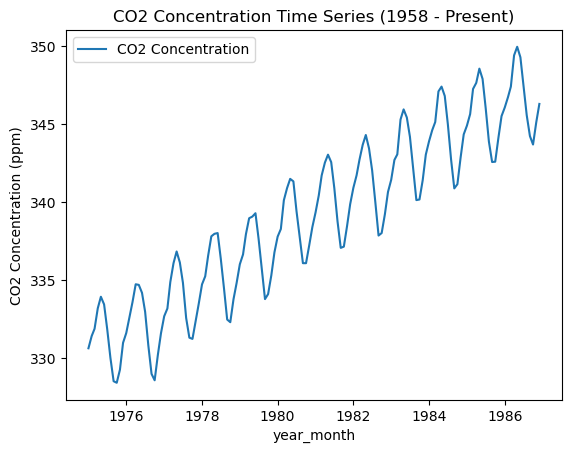

In [7]:
sns.lineplot(df)
plt.title("CO2 Concentration Time Series (1958 - Present)")
plt.ylabel("CO2 Concentration (ppm)")
plt.show()

**Key Takeaway from Visual Inspection:**
The model is an **Additive Model** because the seasonal oscillation height remains uniform throughout.

### Step 5: Additive Seasonal Decomposition
**Why we write this code:**
- `seasonal_decompose(..., model="additive", period=12)`: Splits series into Observed, Trend, Seasonal, and Resid components.

**📊 Detailed Graph Explanation (Graph 2 - Additive Decomposition):**
1. **Observed**: Original CO2 curve.
2. **Trend**: Smooth line showing long-term atmospheric CO2 accumulation.
3. **Seasonal**: Uniform annual wave pattern (12-month period).
4. **Resid**: Minimal residual noise.

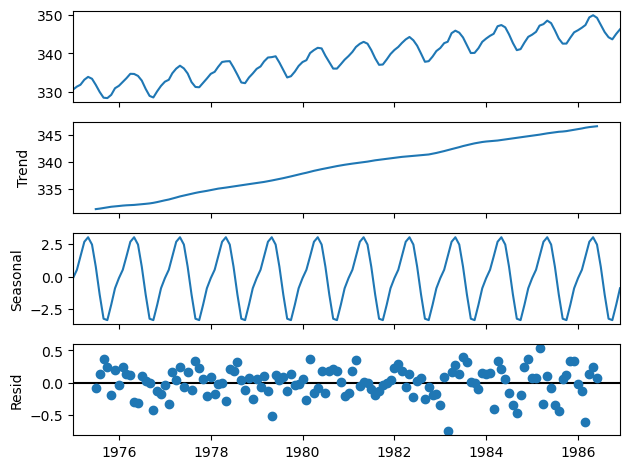

In [8]:
# decomposition of the time series - additive model
result = seasonal_decompose(df[["CO2 Concentration"]], model = "additive", period = 12)
result.plot()
plt.show()

### Step 6: Mann-Kendall Statistical Test for Monotonic Trend
**Why we write this code:**
- `pymannkendall.original_test(df["CO2 Concentration"])`: Confirms statistically if a monotonic upward trend exists ($H_0$: No trend vs $H_1$: Trend exists).

In [9]:
# Perform the Mann-Kendall test
# H0: There is no monotonic trend in the series
import pymannkendall as mk
mk.original_test(df["CO2 Concentration"])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.22737013469656), Tau=np.float64(0.7438811188811189), s=np.float64(7659.0), var_s=np.float64(335184.3333333333), slope=np.float64(0.11999999999999982), intercept=np.float64(330.545))

### Step 7: Train-Test Split (70% Train / 30% Test)
**Why we write this code:**
Split data chronologically without shuffling.

In [10]:
# Train test split (70% Train, 30% Test)
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]
train_df.head(5)

,CO2 Concentration
year_month,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


### Step 8: Exponential Smoothing Models (SES, Holt, Holt-Winters Additive & Multiplicative)
**Why we write this code:**
Fit all 4 models to evaluate forecasting capability on CO2 concentration.

In [11]:
# single exponential smoothing model
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single)

1983-05-01    345.27
1983-06-01    345.27
1983-07-01    345.27
1983-08-01    345.27
1983-09-01    345.27
1983-10-01    345.27
1983-11-01    345.27
1983-12-01    345.27
1984-01-01    345.27
1984-02-01    345.27
1984-03-01    345.27
1984-04-01    345.27
1984-05-01    345.27
1984-06-01    345.27
1984-07-01    345.27
1984-08-01    345.27
1984-09-01    345.27
1984-10-01    345.27
1984-11-01    345.27
1984-12-01    345.27
1985-01-01    345.27
1985-02-01    345.27
1985-03-01    345.27
1985-04-01    345.27
1985-05-01    345.27
1985-06-01    345.27
1985-07-01    345.27
1985-08-01    345.27
1985-09-01    345.27
1985-10-01    345.27
1985-11-01    345.27
1985-12-01    345.27
1986-01-01    345.27
1986-02-01    345.27
1986-03-01    345.27
1986-04-01    345.27
1986-05-01    345.27
1986-06-01    345.27
1986-07-01    345.27
1986-08-01    345.27
1986-09-01    345.27
1986-10-01    345.27
1986-11-01    345.27
1986-12-01    345.27
Freq: MS, dtype: float64


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [12]:
model_single_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(330.62),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

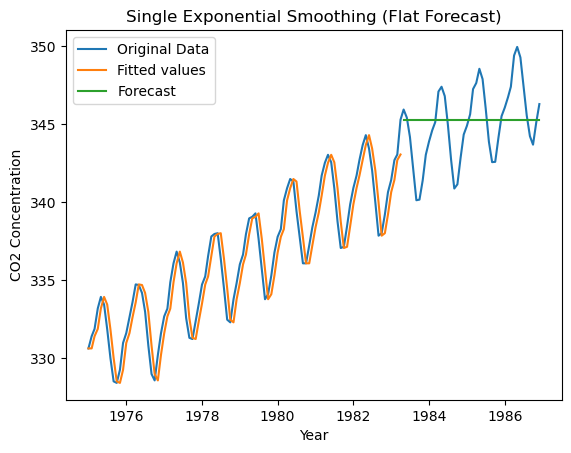

In [13]:
plt.plot(df, label ="Original Data")
plt.plot(model_single_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_single, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Single Exponential Smoothing (Flat Forecast)")
plt.legend()
plt.show()

In [14]:
# DOUBLE EXPONENTIAL SMOOTHING (Holt's model)
from statsmodels.tsa.api import Holt
model_double = Holt(train_df)
model_double_fit = model_double.fit()
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double)

1983-05-01    347.500000
1983-06-01    349.730000
1983-07-01    351.960000
1983-08-01    354.190000
1983-09-01    356.420000
1983-10-01    358.650000
1983-11-01    360.879999
1983-12-01    363.109999
1984-01-01    365.339999
1984-02-01    367.569999
1984-03-01    369.799999
1984-04-01    372.029999
1984-05-01    374.259999
1984-06-01    376.489999
1984-07-01    378.719999
1984-08-01    380.949999
1984-09-01    383.179999
1984-10-01    385.409999
1984-11-01    387.639999
1984-12-01    389.869999
1985-01-01    392.099999
1985-02-01    394.329998
1985-03-01    396.559998
1985-04-01    398.789998
1985-05-01    401.019998
1985-06-01    403.249998
1985-07-01    405.479998
1985-08-01    407.709998
1985-09-01    409.939998
1985-10-01    412.169998
1985-11-01    414.399998
1985-12-01    416.629998
1986-01-01    418.859998
1986-02-01    421.089998
1986-03-01    423.319998
1986-04-01    425.549997
1986-05-01    427.779997
1986-06-01    430.009997
1986-07-01    432.239997
1986-08-01    434.469997


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [15]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.9999999850988388),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(330.62),
 'initial_trend': np.float64(0.7799999999999727),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

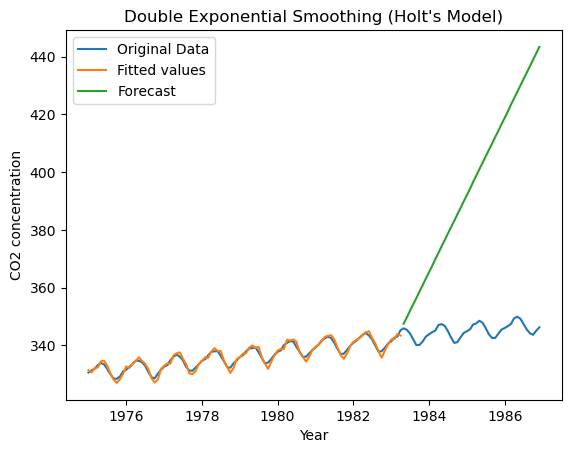

In [16]:
plt.plot(df, label ="Original Data")
plt.plot(model_double_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_double, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 concentration")
plt.title("Double Exponential Smoothing (Holt's Model)")
plt.legend()
plt.show()

In [17]:
# TRIPLE EXPONENTIAL SMOOTHING (HOLT_WINTER'S MODEL) - Additive
from statsmodels.tsa.api import ExponentialSmoothing
# from Pegel's chart, since seasonal amplitude is constant, both trend and seasonality are additive
model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "add")
model_triple_fit = model_triple.fit()
print(model_triple_fit.params)
forecast_triple = model_triple_fit.forecast(len(test_df))
print(forecast_triple)

{'smoothing_level': np.float64(0.45919178464751004), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(330.4849888366404), 'initial_trend': np.float64(0.11765555740061034), 'initial_seasons': array([-0.13511208,  0.53389696,  1.55179602,  2.62525393,  2.88832416,
        2.40441752,  0.74676223, -1.36589244, -3.23354942, -3.37620454,
       -2.24886237, -1.02651923]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
1983-05-01    345.256533
1983-06-01    344.890282
1983-07-01    343.350282
1983-08-01    341.355283
1983-09-01    339.605282
1983-10-01    339.580282
1983-11-01    340.825280
1983-12-01    342.165279
1984-01-01    343.174341
1984-02-01    343.961006
1984-03-01    345.096561
1984-04-01    346.287674
1984-05-01    346.668400
1984-06-01    346.302149
1984-07-01    344.762149
1984-08-01    342.767150
1984-09-01    341.017149
1984-10-01    340.992149
1984-11-01    342.237147
1984-12-01    343.577

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


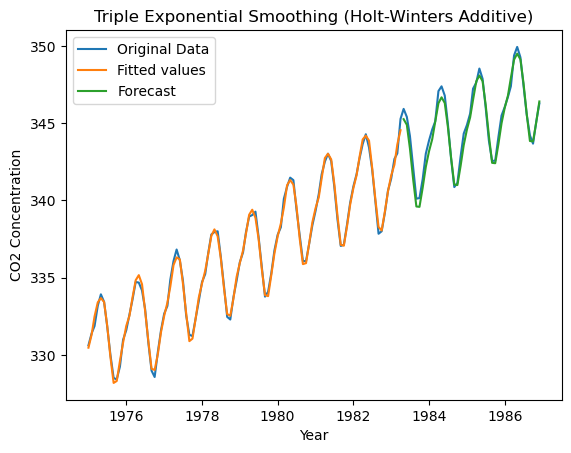

In [18]:
plt.plot(df, label ="Original Data")
plt.plot(model_triple_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Triple Exponential Smoothing (Holt-Winters Additive)")
plt.legend()
plt.show()

In [19]:
# using add-multi model
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "mul")
model_triple_fit_mul = model_triple_mul.fit()
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))
print(forecast_triple_mul)

1983-05-01    345.278578
1983-06-01    344.903040
1983-07-01    343.331233
1983-08-01    341.296927
1983-09-01    339.510714
1983-10-01    339.484592
1983-11-01    340.750761
1983-12-01    342.113214
1984-01-01    343.137395
1984-02-01    343.939306
1984-03-01    345.095577
1984-04-01    346.309652
1984-05-01    346.698006
1984-06-01    346.320439
1984-07-01    344.741689
1984-08-01    342.698546
1984-09-01    340.904521
1984-10-01    340.877815
1984-11-01    342.148702
1984-12-01    343.516264
1985-01-01    344.544165
1985-02-01    345.348882
1985-03-01    346.509409
1985-04-01    347.727974
1985-05-01    348.117434
1985-06-01    347.737837
1985-07-01    346.152145
1985-08-01    344.100165
1985-09-01    342.298327
1985-10-01    342.271038
1985-11-01    343.546643
1985-12-01    344.919315
1986-01-01    345.950935
1986-02-01    346.758458
1986-03-01    347.923241
1986-04-01    349.146296
1986-05-01    349.536862
1986-06-01    349.155236
1986-07-01    347.562602
1986-08-01    345.501784


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


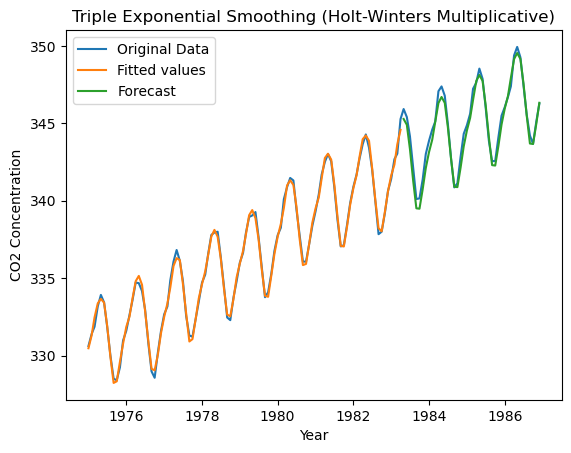

In [20]:
plt.plot(df, label ="Original Data")
plt.plot(model_triple_fit_mul.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple_mul, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Triple Exponential Smoothing (Holt-Winters Multiplicative)")
plt.legend()
plt.show()

### Step 9: Compare MAPE Accuracy Scores
**Why we write this code:**
Evaluate out-of-sample forecast accuracy.

**Observation**: Notice how Additive and Multiplicative models produce virtually **identical MAPE scores**. This happens because when seasonal amplitude does not expand over time, additive and multiplicative formulations yield equivalent forecasts!

In [21]:
# testing for the accuracy of the two models
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test_add = mean_absolute_percentage_error(test_df["CO2 Concentration"], forecast_triple)
print("MAPE Test for Additive Model:", mape_test_add)
mape_test_mul = mean_absolute_percentage_error(test_df["CO2 Concentration"], forecast_triple_mul)
print("MAPE Test for Multiplicative Model:", mape_test_mul)

MAPE Test for Additive Model: 0.0010865977200843833
MAPE Test for Multiplicative Model: 0.0011390922539934204


### Step 10: Stationarity Testing (ADF & KPSS Tests)
**Why we write this code:**
Test baseline raw CO2 data for unit root ($H_0$ in ADF) and trend stationarity ($H_0$ in KPSS).

In [22]:
# ADF Test
# H0: Series is not stationary, i.e., series has a unit root
# H1: Series is stationary, i.e., series has no unit root
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["CO2 Concentration"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
# p-value > 0.05 : fail to reject H0, i.e., series is not stationary

ADF Statistic: -0.6122941400010569
p-value: 0.8681797862771405


In [23]:
# KPSS Test
# H0: Series is trend stationary, i.e., series has no unit root
# H1: Series is non-stationary, i.e., series has a unit root
from statsmodels.tsa.stattools import kpss
kp = kpss(df["CO2 Concentration"])
p = kp[1]
print("p-value for KPSS Test(untransformed) =", p)
# p-value = 0.01 < 0.05: Reject H0, i.e., series is non stationary

p-value for KPSS Test(untransformed) = 0.01


C:\Users\tejas\AppData\Local\Temp\ipykernel_20424\2616326523.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df["CO2 Concentration"])


### Step 11: Combined Seasonal & Non-Seasonal Differencing
**Why we write this code:**
Apply combined differencing `diff(12).diff()` to achieve full stationarity for CO2 Concentration data.

In [24]:
# Combined Differencing for Stationarity
diff_co2 = df["CO2 Concentration"].diff(12).diff().dropna()
result_diff = adfuller(diff_co2)
kp_diff = kpss(diff_co2)
print("Differenced ADF p-value:", result_diff[1], "(Stationary if < 0.05)")
print("Differenced KPSS p-value:", kp_diff[1], "(Stationary if > 0.05)")

Differenced ADF p-value: 4.395427959069439e-05 (Stationary if < 0.05)
Differenced KPSS p-value: 0.1 (Stationary if > 0.05)


C:\Users\tejas\AppData\Local\Temp\ipykernel_20424\3424319773.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp_diff = kpss(diff_co2)
